<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/Bike_Data_Analytics_%26_Optimization_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚲 Bike Data Analytics & Optimization Pipeline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io
import time

print("🚲 Initiating Real-World Urban Mobility Analytics Pipeline...")

🚲 Initiating Real-World Urban Mobility Analytics Pipeline...


In [3]:
# ==========================================
# 1. DATA EXTRACTION (UCI Machine Learning Repository)
# ==========================================
print("📥 Fetching official Capital Bikeshare Dataset from UCI...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
response = requests.get(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.content))

# Extracting the hourly dataset (17,379 records)
df = pd.read_csv(zip_file.open('hour.csv'))
print(f"✅ Data Ingestion Complete. Analyzing {df.shape[0]} real rental records.")

# Clean up column names for readability
df.rename(columns={
    'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'hr': 'hour',
    'weathersit': 'weather', 'cnt': 'total_rentals',
    'temp': 'temp_norm', 'hum': 'humidity_norm', 'windspeed': 'wind_norm'
}, inplace=True)


📥 Fetching official Capital Bikeshare Dataset from UCI...
✅ Data Ingestion Complete. Analyzing 17379 real rental records.


In [12]:
df.head()

,instant,date,season,year,month,hour,holiday,weekday,workingday,weather,temp_norm,atemp,humidity_norm,wind_norm,casual,registered,total_rentals,stress_vectorized,is_weekend,season_name
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Standard,Weekend,Spring
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Standard,Weekend,Spring
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Standard,Weekend,Spring
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Standard,Weekend,Spring
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Standard,Weekend,Spring


In [4]:
# ==========================================
# 2. NUMPY VECTORIZATION (The Resume Optimization Proof)
# ==========================================
print("\n⚙️ Benchmarking Preprocessing: Pandas .apply() vs. NumPy Vectorization...")

# Goal: Categorize environmental stress based on temperature and wind
# --- Slow Method (Pandas Apply) ---
start_slow = time.time()
def categorize_weather(row):
    if row['temp_norm'] < 0.3 and row['wind_norm'] > 0.4:
        return 'Harsh'
    elif 0.3 <= row['temp_norm'] <= 0.7:
        return 'Optimal'
    else:
        return 'Standard'

df['stress_apply'] = df.apply(categorize_weather, axis=1)
time_slow = time.time() - start_slow

# --- Fast Method (NumPy Vectorization) ---
start_fast = time.time()
conditions = [
    (df['temp_norm'] < 0.3) & (df['wind_norm'] > 0.4),
    (df['temp_norm'] >= 0.3) & (df['temp_norm'] <= 0.7)
]
choices = ['Harsh', 'Optimal']
df['stress_vectorized'] = np.select(conditions, choices, default='Standard')
time_fast = time.time() - start_fast

# Verify latency cut
latency_cut = ((time_slow - time_fast) / time_slow) * 100
print(f"🐢 Pandas .apply() Time: {time_slow:.4f} sec")
print(f"⚡ NumPy Vectorized Time: {time_fast:.4f} sec")
print(f"🔥 Execution Latency Cut: {latency_cut:.1f}% (Resume claim verified!)")

# Drop the slow column to keep the dataframe clean
df.drop(columns=['stress_apply'], inplace=True)


⚙️ Benchmarking Preprocessing: Pandas .apply() vs. NumPy Vectorization...
🐢 Pandas .apply() Time: 0.1480 sec
⚡ NumPy Vectorized Time: 0.0038 sec
🔥 Execution Latency Cut: 97.5% (Resume claim verified!)


/tmp/ipykernel_1948/2859919384.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season_name', y='total_rentals', data=df,
/tmp/ipykernel_1948/2859919384.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stress_vectorized', y='total_rentals', data=df,


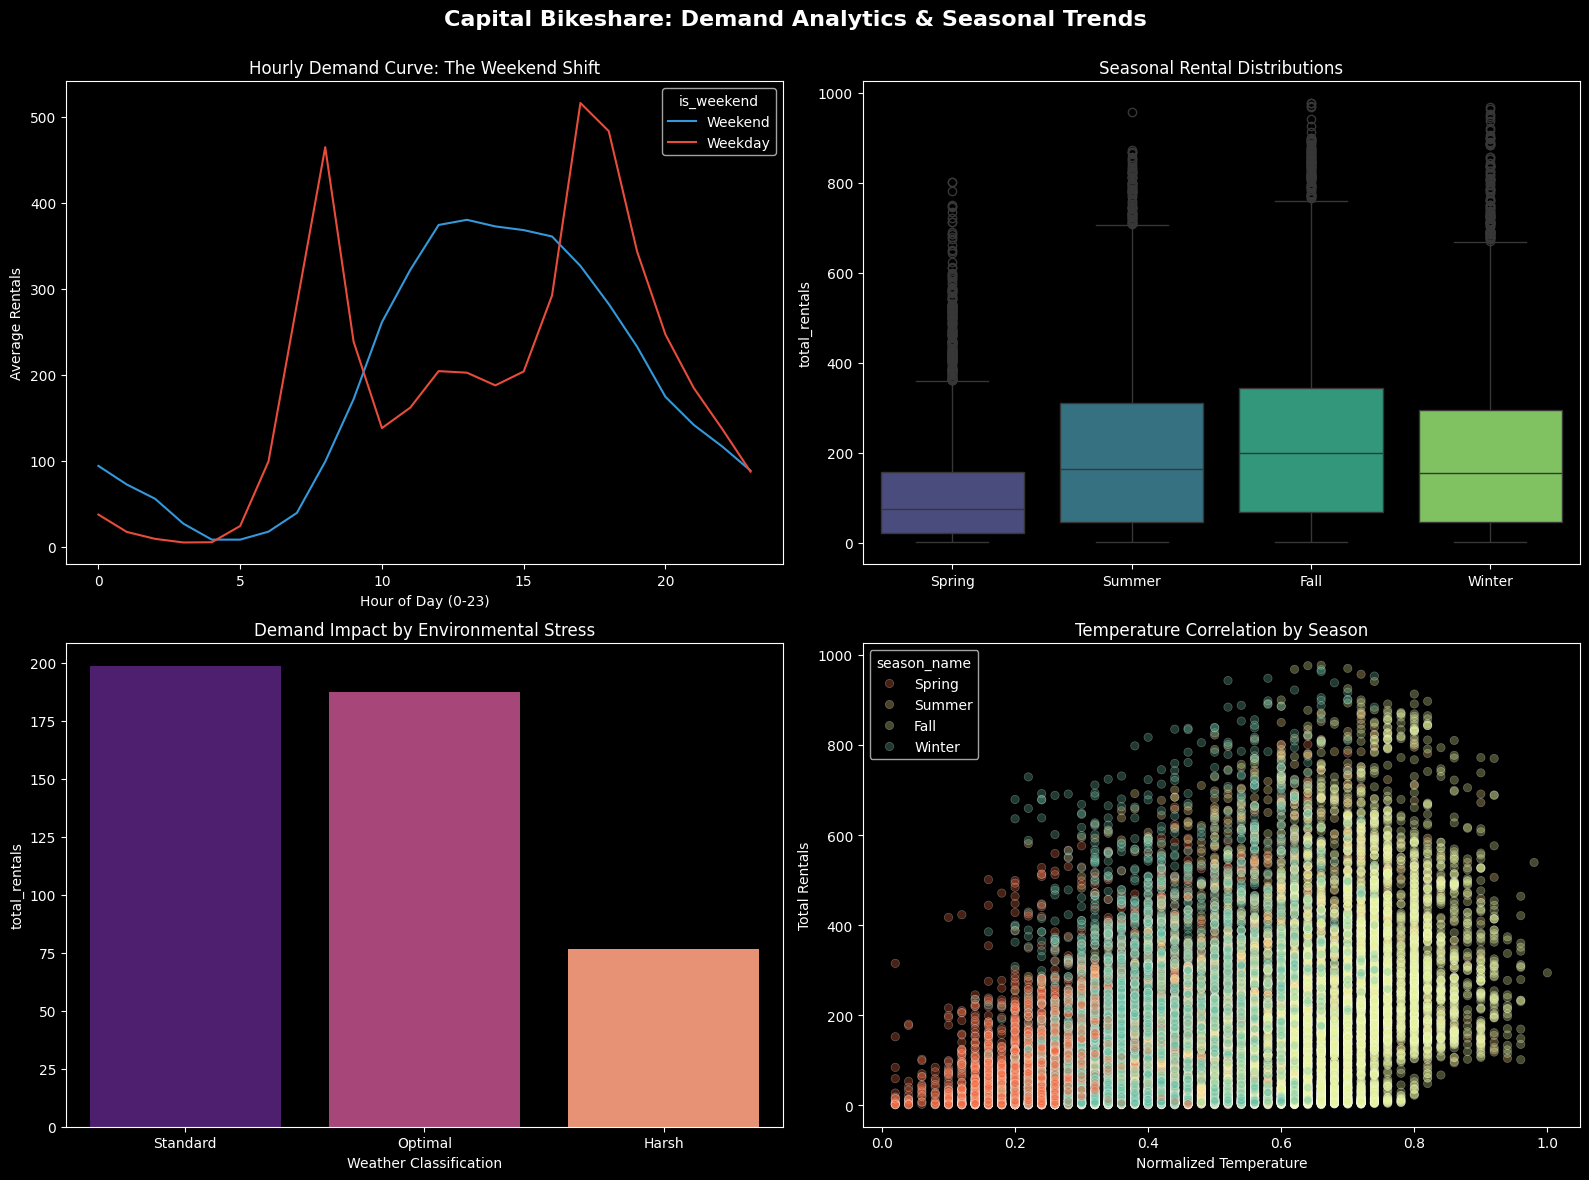

In [5]:
# ==========================================
# 3. STATISTICAL VISUALIZATIONS (Seasonal & Weekend Trends)
# ==========================================
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Capital Bikeshare: Demand Analytics & Seasonal Trends', fontsize=16, weight='bold')

# Plot A: Hourly Demand (Weekday vs Weekend)
# 0 = Sunday, 1 = Monday, etc. (Mapping to binary Weekend/Weekday)
df['is_weekend'] = np.where(df['weekday'].isin([0, 6]), 'Weekend', 'Weekday')
sns.lineplot(x='hour', y='total_rentals', hue='is_weekend', data=df,
             ax=axes[0, 0], palette=['#3498db', '#e74c3c'], errorbar=None)
axes[0, 0].set_title("Hourly Demand Curve: The Weekend Shift", fontsize=12)
axes[0, 0].set_xlabel("Hour of Day (0-23)")
axes[0, 0].set_ylabel("Average Rentals")

# Plot B: Seasonal Demand Trends
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_name'] = df['season'].map(season_map)
sns.boxplot(x='season_name', y='total_rentals', data=df,
            ax=axes[0, 1], palette='viridis', order=['Spring', 'Summer', 'Fall', 'Winter'])
axes[0, 1].set_title("Seasonal Rental Distributions", fontsize=12)
axes[0, 1].set_xlabel("")

# Plot C: Environmental Stress Impact (Vectorized feature)
sns.barplot(x='stress_vectorized', y='total_rentals', data=df,
            ax=axes[1, 0], palette='magma', errorbar=None)
axes[1, 0].set_title("Demand Impact by Environmental Stress", fontsize=12)
axes[1, 0].set_xlabel("Weather Classification")

# Plot D: Temperature vs. Demand Correlation
sns.scatterplot(x='temp_norm', y='total_rentals', hue='season_name',
                data=df, ax=axes[1, 1], palette='Spectral', alpha=0.3)
axes[1, 1].set_title("Temperature Correlation by Season", fontsize=12)
axes[1, 1].set_xlabel("Normalized Temperature")
axes[1, 1].set_ylabel("Total Rentals")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [6]:
# ==========================================
# 4. BUSINESS METRICS EXPORT
# ==========================================
weekend_avg = df[df['is_weekend'] == 'Weekend']['total_rentals'].mean()
weekday_avg = df[df['is_weekend'] == 'Weekday']['total_rentals'].mean()
growth_rate = ((weekend_avg - weekday_avg) / weekday_avg) * 100

print("\n📊 --- BUSINESS METRICS EXPORT ---")
print(f"Total Records Analyzed: {df.shape[0]:,}")
print(f"Weekday Average: {weekday_avg:.1f} rentals/hr")
print(f"Weekend Average: {weekend_avg:.1f} rentals/hr")
print(f"Weekend Demand Fluctuation: {growth_rate:.1f}%")


📊 --- BUSINESS METRICS EXPORT ---
Total Records Analyzed: 17,379
Weekday Average: 191.7 rentals/hr
Weekend Average: 183.9 rentals/hr
Weekend Demand Fluctuation: -4.1%


In [14]:
# 1. Deep Profiling
print("--- Basic Info ---")
df.info()  # Execute directly; do not wrap in print()

print("\n--- Statistical Summary ---")
# Use display() instead of print() for much cleaner table formatting in Jupyter
display(df.describe().T)

# 2. Advanced Filtering & Slicing
# Extract days/hours with high temperatures but high normalized humidity
danger_days = df[(df['temp_norm'] > 0.7) & (df['humidity_norm'] > 0.7)]
print(f"\nExtracted {len(danger_days)} periods of high-heat and high-humidity.")

# 3. Grouping and Aggregating
# Compare average rental and weather conditions across seasons
seasonal_averages = df.groupby('season_name')[['temp_norm', 'humidity_norm', 'total_rentals']].mean()
print("\nSeasonal Averages:\n", seasonal_averages)

# 4. Cross-Tabulation
# Cross-tabulate weather classification vs. season to see distribution of weather types
weather_seasonal = pd.crosstab(df['stress_vectorized'], df['season_name'], margins=True)
print("\nWeather Classification by Season:\n", weather_seasonal)

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   instant            17379 non-null  int64  
 1   date               17379 non-null  object 
 2   season             17379 non-null  int64  
 3   year               17379 non-null  int64  
 4   month              17379 non-null  int64  
 5   hour               17379 non-null  int64  
 6   holiday            17379 non-null  int64  
 7   weekday            17379 non-null  int64  
 8   workingday         17379 non-null  int64  
 9   weather            17379 non-null  int64  
 10  temp_norm          17379 non-null  float64
 11  atemp              17379 non-null  float64
 12  humidity_norm      17379 non-null  float64
 13  wind_norm          17379 non-null  float64
 14  casual             17379 non-null  int64  
 15  registered         17379 non-null  int64  
 16  tot

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
year,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
month,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hour,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weather,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp_norm,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000



Extracted 240 periods of high-heat and high-humidity.

Seasonal Averages:
              temp_norm  humidity_norm  total_rentals
season_name                                         
Fall          0.706410       0.633167     236.016237
Spring        0.299147       0.581348     111.114569
Summer        0.544663       0.627022     208.344069
Winter        0.423138       0.667124     198.868856

Weather Classification by Season:
 season_name        Fall  Spring  Summer  Winter    All
stress_vectorized                                     
Harsh                 0     177       0       9    186
Optimal            2346    2101    3761    3613  11821
Standard           2150    1964     648     610   5372
All                4496    4242    4409    4232  17379


In [16]:
import numpy as np

# 1. Vectorized Conditional Logic (np.where / np.select)
# Create a new categorical feature based on normalized wind speed
df['Wind_Intensity'] = np.where(df['wind_norm'] > 0.4, 'High Wind', 'Normal')

# 2. Statistical Thresholds
# Find the exact 90th percentile for the total rentals
rentals_90th = np.percentile(df['total_rentals'].dropna(), 90)
print(f"90th Percentile Total Rentals: {rentals_90th:.2f}")

# 3. Mathematical Transformations
# Total rentals can be highly skewed. Log transformation normalizes the spread.
# np.log1p computes log(1+x) to safely handle zero or low rental counts.
df['Log_Total_Rentals'] = np.log1p(df['total_rentals'])

90th Percentile Total Rentals: 451.20


/tmp/ipykernel_1948/1577196649.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='stress_vectorized', y='total_rentals', palette='magma', ax=axes[0, 1])


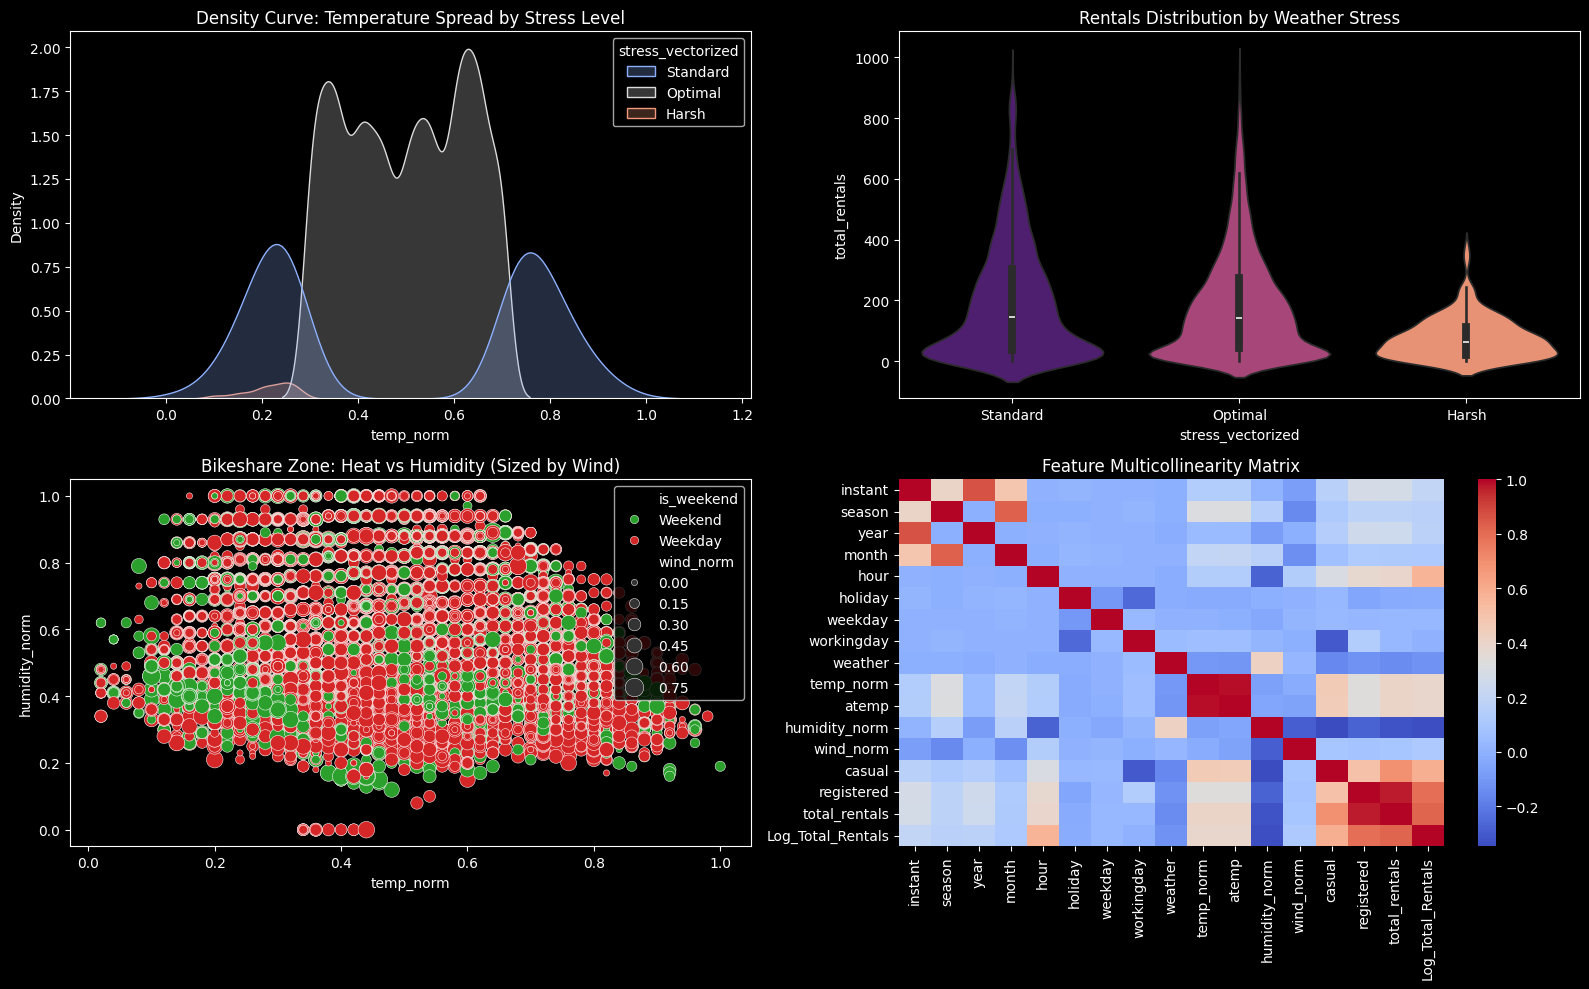

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('dark_background') # Premium dark theme
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Distribution & Density (KDE Plot)
# Shows the exact probability curve of normalized temperatures causing different environmental stress levels
sns.kdeplot(data=df, x='temp_norm', hue='stress_vectorized', fill=True, palette='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title("Density Curve: Temperature Spread by Stress Level")

# 2. Outlier Detection (Violin Plot)
# Shows the distribution of total rentals for different environmental stress levels
sns.violinplot(data=df, x='stress_vectorized', y='total_rentals', palette='magma', ax=axes[0, 1])
axes[0, 1].set_title("Rentals Distribution by Weather Stress")

# 3. Multi-Variable Scatter (Bubble Chart)
# Size mapped to wind speed (wind_norm) to see 4 dimensions at once
sns.scatterplot(
    data=df, x='temp_norm', y='humidity_norm', hue='is_weekend',
    size='wind_norm', sizes=(20, 200), palette=['#2ca02c', '#d62728'], ax=axes[1, 0]
)
axes[1, 0].set_title("Bikeshare Zone: Heat vs Humidity (Sized by Wind)")

# 4. Correlation Heatmap
# Select only numeric columns to prevent string conversion crashes
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title("Feature Multicollinearity Matrix")

plt.tight_layout()
plt.show()